# Default assumed user expertise — figures

Run top to bottom. Figures save to `results/`.

| exp | anchors | source |
|---|---|---|
| 1 | style-written expert/novice prompts | `data/acts.npz` |
| 2 | addressed suffixes, behavioural readout | `results/behavior.jsonl` |
| 3 | addressed suffixes, activation readout, presupposition-split | `results/probe2_positions.npz` |

In [1]:
%load_ext autoreload
%autoreload 2
import json, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import spearmanr
from config import TOPICS, DATA, RESULTS
from probe2 import FAMILIES
import analyze as A

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
T = list(TOPICS); FAM = list(FAMILIES)
NOV, EXP, BEH, GREY = '#c0603a', '#3a6ea5', '#5b8c5a', '#bbbbbb'
FC = {'pre': '#7fa8d0', 'post': '#2a5580'}
RESULTS.mkdir(exist_ok=True)
rng = np.random.default_rng(0)

def boot(x, n=4000):
    x = np.asarray(x)
    return np.percentile(rng.choice(x, (n, len(x)), replace=True).mean(1), [2.5, 97.5])

def perm_p(groups, n=5000):
    obs = np.var([g.mean() for g in groups])
    flat, sz = np.concatenate(groups), [len(g) for g in groups]
    null = np.array([np.var([x.mean() for x in
                     np.split(rng.permutation(flat), np.cumsum(sz)[:-1])]) for _ in range(n)])
    return obs, (null >= obs).mean()

def decomp(d):
    within = np.mean([v.var(ddof=1) for v in d.values()])
    n = np.mean([len(v) for v in d.values()])
    mu = np.array([v.mean() for v in d.values()])
    return within, within / n, max(mu.var(ddof=1) - within / n, 0.0)

In [2]:
f = np.load(RESULTS / 'probe2_positions.npz')
auc2, L2 = f['aucs'], int(f['layer'])
pos = {tuple(k.split('|')): f[k] for k in f.files if '|' in k and not k.startswith('bow')}
bow = {k.split('|')[1]: f[k] for k in f.files if k.startswith('bow')}
both = {(t, fam): np.concatenate([pos[(t, fam, 'A')], pos[(t, fam, 'B')]])
        for t in T for fam in FAM}
print(f'layer {L2}, L0 AUC {auc2[0]:.3f}, peak {auc2.max():.3f}')

layer 19, L0 AUC 0.651, peak 1.000


## Fig 1 — the confound and the fix

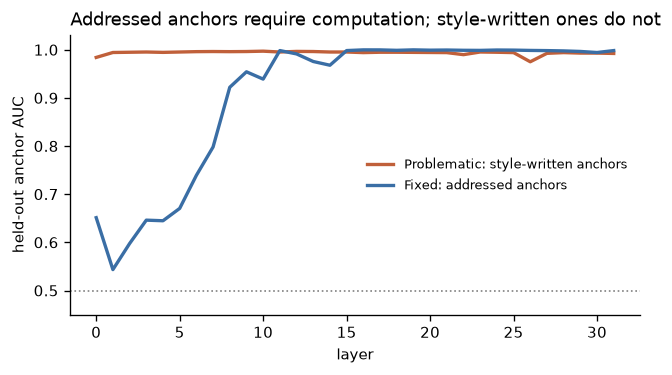

Problematic L0=0.984  Fixed L0=0.651


In [7]:
acts1, topic1, label1, idx1 = A.load(DATA / 'acts.npz')
sweep1 = A.layer_sweep(acts1, topic1, label1, idx1, T)
auc1 = sweep1.mean(1); L1 = int(auc1.argmax())

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(auc1, lw=2, color=NOV, label='Problematic: style-written anchors')
ax.plot(auc2, lw=2, color=EXP, label='Fixed: addressed anchors')
ax.axhline(.5, ls=':', c='gray', lw=1)
ax.set_xlabel('layer'); ax.set_ylabel('held-out anchor AUC'); ax.set_ylim(.45, 1.03)
ax.legend(frameon=False, loc='center right', fontsize=8)
ax.set_title('Addressed anchors require computation; style-written ones do not', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig1_layer_sweep.png', bbox_inches='tight'); plt.show()
print(f'Problematic L0={auc1[0]:.3f}  Fixed L0={auc2[0]:.3f}')

## Fig 2 — presupposition effect (the manipulation)

pre   +0.194  [+0.180, +0.209]  sd 0.077
post  +0.383  [+0.348, +0.417]  sd 0.176
effect = +0.189


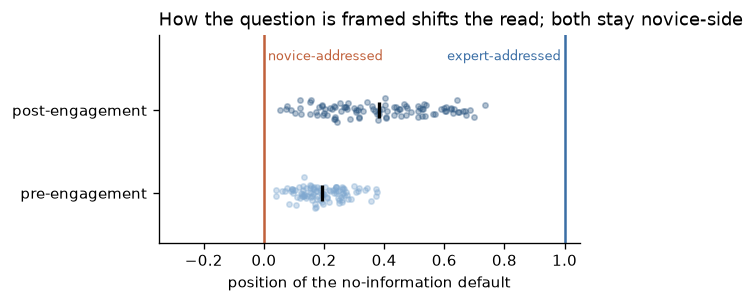

In [4]:
fv = {fam: np.concatenate([both[(t, fam)] for t in T]) for fam in FAM}
for fam in FAM:
    c = boot(fv[fam])
    print(f'{fam:5s} {fv[fam].mean():+.3f}  [{c[0]:+.3f}, {c[1]:+.3f}]  sd {fv[fam].std(ddof=1):.3f}')
print(f'effect = {fv["post"].mean() - fv["pre"].mean():+.3f}')

fig, ax = plt.subplots(figsize=(5, 2.6))
for i, fam in enumerate(FAM):
    ax.scatter(fv[fam], np.full(len(fv[fam]), i) + rng.normal(0, .06, len(fv[fam])),
               s=10, alpha=.35, color=FC[fam])
    ax.scatter([fv[fam].mean()], [i], s=90, marker='|', color='k', zorder=4, lw=2)
ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
ax.text(0, 1.6, ' novice-addressed', color=NOV, fontsize=8)
ax.text(1, 1.6, 'expert-addressed ', color=EXP, fontsize=8, ha='right')
ax.set_yticks(range(len(FAM))); ax.set_yticklabels(['pre-engagement', 'post-engagement'])
ax.set_xlim(-.35, 1.05); ax.set_ylim(-.6, 1.9)
ax.set_xlabel('position of the no-information default')
ax.set_title('How the question is framed shifts the read; both stay novice-side', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig2_presupposition.png', bbox_inches='tight'); plt.show()

In [8]:
from config import TOPICS
from probe2 import FAMILIES
for f, ts in FAMILIES.items():
    for tm in ts:
        for k, d in TOPICS.items():
            print(f"[{f}] {tm.format(t=d)}")
    print()


[pre] I'm about to get into sourdough bread baking again. What should I know going in?
[pre] I'm about to get into chemotherapy treatment decisions again. What should I know going in?
[pre] I'm about to get into python programming again. What should I know going in?
[pre] I'm about to get into mortgage refinancing again. What should I know going in?
[pre] I'm about to get into car engine repair again. What should I know going in?
[pre] I'm about to get into music theory and composition again. What should I know going in?
[pre] I'm about to get into personal income tax law again. What should I know going in?
[pre] I'm about to get into houseplant care again. What should I know going in?
[pre] I'm about to get into machine learning research again. What should I know going in?
[pre] I'm about to get into strength training programming again. What should I know going in?
[pre] I've got something coming up involving sourdough bread baking. Where should I start?
[pre] I've got something comin

## Fig 3 — domain, within each family

pre   within=0.0044 (sd 0.066)  between obs=0.00187 floor=0.00044 true=0.00164 (sd 0.040)  p=0.000
post  within=0.0277 (sd 0.167)  between obs=0.00559 floor=0.00277 true=0.00344 (sd 0.059)  p=0.025


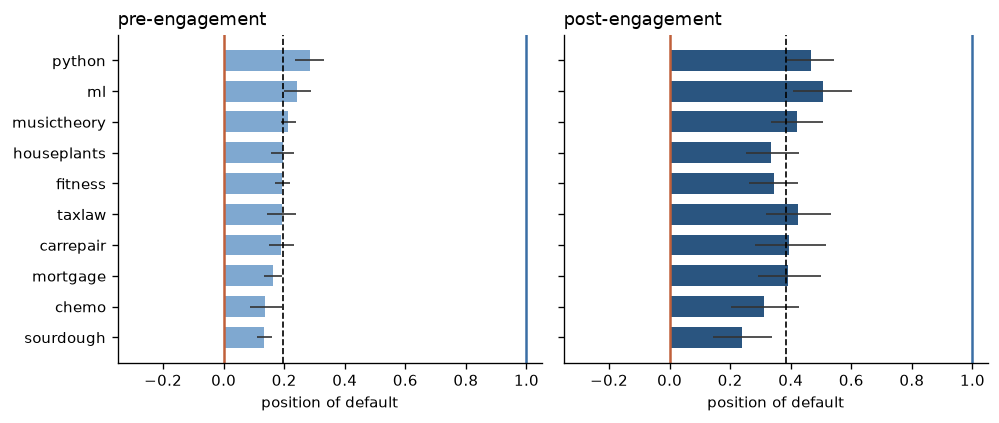

In [5]:
for fam in FAM:
    d = {t: both[(t, fam)] for t in T}
    w, floor, true_b = decomp(d)
    obs, p = perm_p([d[t] for t in T])
    print(f'{fam:5s} within={w:.4f} (sd {np.sqrt(w):.3f})  between obs={obs:.5f} '
          f'floor={floor:.5f} true={true_b:.5f} (sd {np.sqrt(true_b):.3f})  p={p:.3f}')

order = sorted(T, key=lambda t: both[(t, 'pre')].mean())
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), sharey=True)
for ax, fam in zip(axes, FAM):
    mu = np.array([both[(t, fam)].mean() for t in order])
    ci = np.array([boot(both[(t, fam)]) for t in order])
    ax.barh(range(len(order)), mu, color=FC[fam], height=.68,
            xerr=np.abs(ci.T - mu), error_kw=dict(lw=1, ecolor='#333'))
    ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
    ax.axvline(np.concatenate([both[(t, fam)] for t in T]).mean(), ls='--', c='k', lw=1)
    ax.set_xlim(-.35, 1.05); ax.set_title(fam + '-engagement', loc='left')
    ax.set_xlabel('position of default')
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order)
plt.tight_layout(); plt.savefig(RESULTS / 'fig3_domain.png', bbox_inches='tight'); plt.show()

## Fig 4 — controls: stability, template residual, BoW

paraphrase-set stability (same text, different anchors)
  pre   var(A vs B)=0.0000   vs within-topic 0.0062   ratio 0.00
  post  var(A vs B)=0.0007   vs within-topic 0.0184   ratio 0.04

template means within family
  pre   +0.10  How do I get started with {t}?
  pre   +0.17  What should I know before trying {t}?
  pre   +0.30  What's the first thing to do with {t}?
  pre   +0.12  Where do I begin with {t}?
  pre   +0.18  What do I need to know about {t}?
  post  +0.32  I tried {t} and it didn't go how I expected. Any ideas?
  post  +0.27  My {t} isn't working right. What should I check?
  post  +0.59  I've been doing {t} but something's off. Any thoughts?
  post  +0.51  I ran into a problem with {t}. What's likely going on?
  post  +0.38  {t} isn't behaving the way I thought. Where should I look?


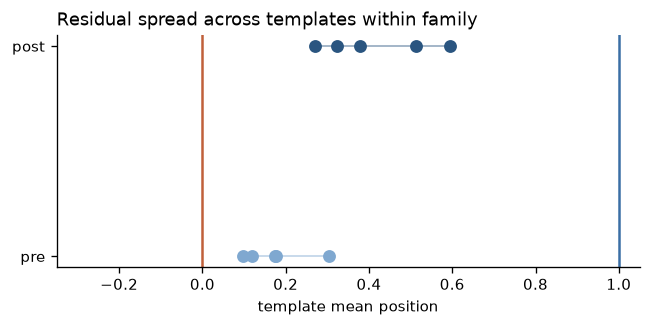

In [6]:
print('paraphrase-set stability (same text, different anchors)')
for fam in FAM:
    v = np.mean([np.var(np.stack([pos[(t, fam, 'A')], pos[(t, fam, 'B')]]), axis=0).mean()
                 for t in T])
    w, _, _ = decomp({t: both[(t, fam)] for t in T})
    print(f'  {fam:5s} var(A vs B)={v:.4f}   vs within-topic {w:.4f}   ratio {v/w:.2f}')

print('\ntemplate means within family')
tm = {}
for fam in FAM:
    v = np.stack([both[(t, fam)].reshape(2, -1).mean(0) for t in T])
    tm[fam] = v.mean(0)
    for i, s in enumerate(FAMILIES[fam]):
        print(f'  {fam:5s} {v[:, i].mean():+.2f}  {s}')

fig, ax = plt.subplots(figsize=(5.5, 2.8))
for i, fam in enumerate(FAM):
    ax.scatter(tm[fam], np.full(len(tm[fam]), i), s=45, color=FC[fam], zorder=3)
    ax.plot([tm[fam].min(), tm[fam].max()], [i, i], color=FC[fam], lw=1, alpha=.5)
ax.set_yticks(range(len(FAM))); ax.set_yticklabels(['pre', 'post'])
ax.set_xlabel('template mean position'); ax.set_xlim(-.35, 1.05)
ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
ax.set_title('Residual spread across templates within family', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig4_template_residual.png', bbox_inches='tight'); plt.show()

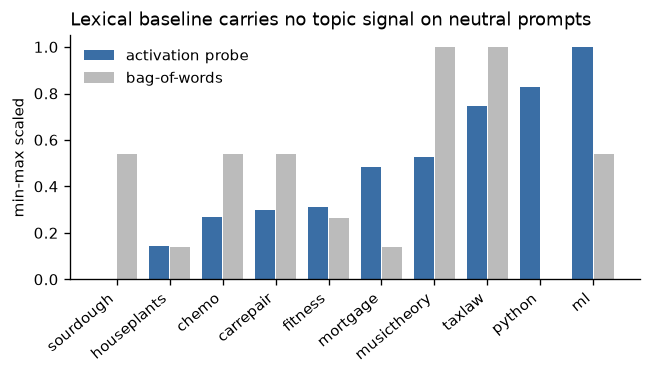

BoW raw range 0.0283   probe raw range 0.2119


In [7]:
def mm(v):
    v = np.asarray(v); return (v - v.min()) / (v.max() - v.min())
pv = mm([np.concatenate([both[(t, fam)] for fam in FAM]).mean() for t in T])
bv = mm([bow[t].mean() for t in T])
o = np.argsort(pv); x = np.arange(len(T))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(x - .2, pv[o], .38, color=EXP, label='activation probe')
ax.bar(x + .2, bv[o], .38, color=GREY, label='bag-of-words')
ax.set_xticks(x); ax.set_xticklabels([T[i] for i in o], rotation=40, ha='right')
ax.set_ylabel('min-max scaled'); ax.legend(frameon=False)
ax.set_title('Lexical baseline carries no topic signal on neutral prompts', loc='left')
plt.tight_layout(); plt.savefig(RESULTS / 'fig5_bow_control.png', bbox_inches='tight'); plt.show()
raw = [bow[t].mean() for t in T]
print(f'BoW raw range {max(raw)-min(raw):.4f}   probe raw range '
      f'{max(np.concatenate([both[(t,f)] for f in FAM]).mean() for t in T) - min(np.concatenate([both[(t,f)] for f in FAM]).mean() for t in T):.4f}')

## Exp 2 — behavioural, same stimuli

anchor separation (expert - novice)
  long_word_frac      0.057   same sign in 100%
  mean_sent_len       1.128   same sign in 100%
  hedges              0.233   same sign in  90%
  defines             0.252   same sign in 100%
  simplifies         -0.078   same sign in   0%
  bullets            -0.026   same sign in  50%


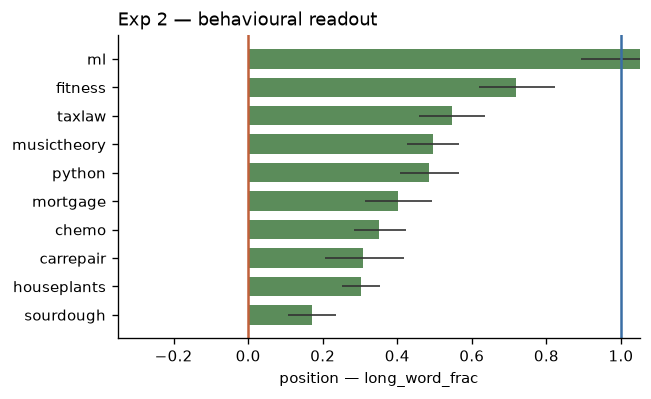


convergence probe vs behaviour: SignificanceResult(statistic=np.float64(0.6484848484848483), pvalue=np.float64(0.04254012768448949))


In [8]:
try:
    beh = [json.loads(l) for l in open(RESULTS / 'behavior.jsonl')]
except FileNotFoundError:
    beh = []

if beh:
    FEATS = ['long_word_frac', 'mean_sent_len', 'hedges', 'defines', 'simplifies', 'bullets']
    g = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for r in beh:
        for ft in FEATS:
            g[ft][r['topic']][r['arm']].append(r[ft])
    print('anchor separation (expert - novice)')
    for ft in FEATS:
        sep = [np.mean(g[ft][t]['expert']) - np.mean(g[ft][t]['novice']) for t in g[ft]]
        print(f'  {ft:16s} {np.mean(sep):8.3f}   same sign in {np.mean([s>0 for s in sep])*100:3.0f}%')

    FEAT = 'long_word_frac'
    bpos = {}
    for t, arms in g[FEAT].items():
        lo_, hi_ = np.mean(arms['novice']), np.mean(arms['expert'])
        if abs(hi_ - lo_) > 1e-6:
            bpos[t] = (np.array(arms['neutral']) - lo_) / (hi_ - lo_)
    bo = sorted(bpos, key=lambda t: bpos[t].mean())
    bm = np.array([bpos[t].mean() for t in bo]); bc = np.array([boot(bpos[t]) for t in bo])
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.barh(range(len(bo)), bm, color=BEH, height=.68,
            xerr=np.abs(bc.T - bm), error_kw=dict(lw=1, ecolor='#333'))
    ax.axvline(0, c=NOV, lw=1.5); ax.axvline(1, c=EXP, lw=1.5)
    ax.set_yticks(range(len(bo))); ax.set_yticklabels(bo)
    ax.set_xlabel(f'position — {FEAT}'); ax.set_xlim(-.35, 1.05)
    ax.set_title('Exp 2 — behavioural readout', loc='left')
    plt.tight_layout(); plt.savefig(RESULTS / 'fig6_behaviour.png', bbox_inches='tight'); plt.show()

    sh = [t for t in T if t in bpos]
    pvv = [np.concatenate([both[(t, fam)] for fam in FAM]).mean() for t in sh]
    bvv = [bpos[t].mean() for t in sh]
    print('\nconvergence probe vs behaviour:', spearmanr(pvv, bvv))

In [10]:
from scipy.stats import spearmanr
import numpy as np
b = np.load(RESULTS/'behavior_positions.npz')
p = np.load(RESULTS/'probe2_positions.npz')
ks = [k for k in b.files if '|' in k]
bv = [float(b[k][0]) for k in ks]
pv = [np.concatenate([p[f"{k}|A"], p[f"{k}|B"]]).mean() for k in ks]
print(spearmanr(pv, bv), len(ks))


SignificanceResult(statistic=np.float64(0.5969924812030075), pvalue=np.float64(0.0054519893833496)) 20


In [12]:
import numpy as np
from scipy.stats import spearmanr, pearsonr
from config import RESULTS, TOPICS

b = np.load(RESULTS / "behavior_positions.npz")
p = np.load(RESULTS / "probe2_positions.npz")

rows = []
for k in b.files:
    if "|" not in k:
        continue
    topic, fam = k.split("|")
    if f"{topic}|{fam}|A" not in p.files:
        print(f"  no probe data for {k}, skipping")
        continue
    rows.append((topic, fam,
                 np.concatenate([p[f"{topic}|{fam}|A"], p[f"{topic}|{fam}|B"]]).mean(),
                 float(b[k][0])))

print(f"{'topic':14s}{'family':>7s}{'probe':>9s}{'behav':>9s}")
for t, f, pv, bv in sorted(rows, key=lambda r: (r[1], r[2])):
    print(f"{t:14s}{f:>7s}{pv:9.3f}{bv:9.3f}")

pv = np.array([r[2] for r in rows])
bv = np.array([r[3] for r in rows])
r = spearmanr(pv, bv)
print(f"\npooled   rho={r.statistic:+.3f}  p={r.pvalue:.4f}  n={len(rows)}")
pr = pearsonr(pv, bv)
print(f"         pearson r={pr.statistic:+.3f}  p={pr.pvalue:.4f}")

for fam in sorted({r[1] for r in rows}):
    sub = [r for r in rows if r[1] == fam]
    x = np.array([s[2] for s in sub]); y = np.array([s[3] for s in sub])
    rr = spearmanr(x, y)
    print(f"{fam:8s} rho={rr.statistic:+.3f}  p={rr.pvalue:.4f}  n={len(sub)}")




topic          family    probe    behav
sourdough        post    0.238    0.154
chemo            post    0.311    0.423
houseplants      post    0.335    0.232
fitness          post    0.343    0.333
mortgage         post    0.391    0.339
carrepair        post    0.394    0.226
musictheory      post    0.420    0.423
taxlaw           post    0.425    0.687
python           post    0.466    0.534
ml               post    0.507    0.472
sourdough         pre    0.134    0.139
chemo             pre    0.138    0.207
mortgage          pre    0.162    0.250
carrepair         pre    0.188    0.354
taxlaw            pre    0.192    0.396
fitness           pre    0.194    0.244
houseplants       pre    0.196    0.162
musictheory       pre    0.214    0.195
ml                pre    0.243    0.311
python            pre    0.284    0.169

pooled   rho=+0.597  p=0.0055  n=20
         pearson r=+0.664  p=0.0014
post     rho=+0.758  p=0.0111  n=10
pre      rho=-0.006  p=0.9867  n=10


In [15]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from config import RESULTS

plt.rcParams.update({"font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
PROBE, BEHAV = "#3a6ea5", "#5b8c5a"
FC = {"pre": "#7fa8d0", "post": "#2a5580"}
FAM = ["pre", "post"]

b = np.load(RESULTS / "behavior_positions.npz")
p = np.load(RESULTS / "probe2_positions.npz")

rows = []
for k in b.files:
    if "|" not in k:
        continue
    t, f = k.split("|")
    if f"{t}|{f}|A" not in p.files:
        continue
    rows.append((t, f,
                 np.concatenate([p[f"{t}|{f}|A"], p[f"{t}|{f}|B"]]).mean(),
                 float(b[k][0])))
RESULTS.mkdir(exist_ok=True)

# ---- figure 1: levels --------------------------------------------------
m = {(f, s): np.mean([r[2 if s == "probe" else 3] for r in rows if r[1] == f])
     for f in FAM for s in ("probe", "behav")}
fig, ax = plt.subplots(figsize=(4.4, 3.4))
x = np.arange(2)
ax.bar(x - .19, [m[(f, "probe")] for f in FAM], .36, color=PROBE, label="probe (Exp 1)")
ax.bar(x + .19, [m[(f, "behav")] for f in FAM], .36, color=BEHAV, label="behavioral (Exp 2)")
for i, f in enumerate(FAM):
    for o, s in ((-.19, "probe"), (.19, "behav")):
        ax.text(i + o, m[(f, s)] + .015, f"{m[(f,s)]:.2f}", ha="center", fontsize=8)
ax.axhline(1, c="#c0603a", lw=1.2, ls="--")
ax.text(1.46, 1.02, "expert anchor", color="#c0603a", fontsize=7.5, ha="right")
ax.set_xticks(x); ax.set_xticklabels(["pre-engagement", "post-engagement"])
ax.set_ylim(0, 1.14); ax.set_ylabel("position of the no-information default")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_title("Two measures put the default in the same place", loc="left")
plt.tight_layout(); plt.savefig(RESULTS / "fig_conv_levels.png", dpi=170,
                                bbox_inches="tight"); plt.close()

# ---- figure 2: per-family scatters, shared axes ------------------------
allv = [v for r in rows for v in (r[2], r[3])]
lo, hi = min(allv) - .06, max(allv) + .06
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.9), sharex=True, sharey=True)
for a, f in zip(axes, FAM):
    sub = [r for r in rows if r[1] == f]
    xs = np.array([s[2] for s in sub]); ys = np.array([s[3] for s in sub])
    r = spearmanr(xs, ys)
    a.plot([lo, hi], [lo, hi], ls=":", c="gray", lw=1)
    if r.pvalue < .05:
        a.plot([lo, hi], np.polyval(np.polyfit(xs, ys, 1), [lo, hi]),
               ls="--", c=FC[f], lw=1.3)
    a.scatter(xs, ys, s=44, color=FC[f], zorder=3)
    for s in sub:
        a.annotate(s[0], (s[2], s[3]), fontsize=7,
                   xytext=(5, 3), textcoords="offset points")
    a.set_xlim(lo, hi); a.set_ylim(lo, hi)
    a.set_xlabel("probe position")
    sig = f"p = {r.pvalue:.3f}" if r.pvalue < .05 else "n.s."
    a.set_title(f"{f}-engagement:  $\\rho$ = {r.statistic:+.2f}  ({sig})", loc="left")
    print(f"{f:5s} rho={r.statistic:+.3f} p={r.pvalue:.4f} n={len(sub)}")
axes[0].set_ylabel("behavioural position")
plt.tight_layout(); plt.savefig(RESULTS / "fig_conv_topics.png", dpi=170,
                                bbox_inches="tight"); plt.close()

pooled = spearmanr([r[2] for r in rows], [r[3] for r in rows])
print(f"pooled rho={pooled.statistic:+.3f} p={pooled.pvalue:.4f} "
      "— confounded by family, do not headline")
print("->", RESULTS / "fig_conv_levels.png", "|", RESULTS / "fig_conv_topics.png")




pre   rho=-0.006 p=0.9867 n=10
post  rho=+0.758 p=0.0111 n=10
pooled rho=+0.597 p=0.0055 — confounded by family, do not headline
-> /workspace/mats/results/fig_conv_levels.png | /workspace/mats/results/fig_conv_topics.png


## Summary table

In [ ]:
import csv
with open(RESULTS / 'summary.csv', 'w', newline='') as fh:
    w = csv.writer(fh)
    w.writerow(['topic', 'pre', 'pre_lo', 'pre_hi', 'post', 'post_lo', 'post_hi', 'behaviour'])
    for t in T:
        row = [t]
        for fam in FAM:
            c = boot(both[(t, fam)])
            row += [round(both[(t, fam)].mean(), 3), round(c[0], 3), round(c[1], 3)]
        row.append(round(bpos[t].mean(), 3) if beh and t in bpos else '')
        w.writerow(row)
print(open(RESULTS / 'summary.csv').read())

## Experiment 3

In [24]:
import json, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict, Counter
from config import RESULTS

st = [json.loads(l) for l in open(RESULTS / "steer_test.jsonl")]
print(Counter(r["alpha"] for r in st))
print("rows with ascii_frac:", sum("ascii_frac" in r for r in st), "/", len(st))

FEATS = ["long_word_frac", "defines", "hedges", "simplifies", "mean_sent_len"]
NONMONO = {"mean_sent_len"}
LABEL = {"long_word_frac": "long-word fraction", "defines": "unprompted definitions",
         "hedges": "hedging", "simplifies": "simplifying language",
         "mean_sent_len": "sentence length"}
COL = {"long_word_frac": "#2a5580", "defines": "#3f8f5b", "hedges": "#c07a2c",
       "simplifies": "#9c4f8e", "mean_sent_len": "#c9c9c9"}

g = defaultdict(lambda: defaultdict(list))
for r in st:
    for k in FEATS:
        g[r["alpha"]][k].append(r[k])
alphas = np.array(sorted(g))
mu = {k: np.array([np.mean(g[a][k]) for a in alphas]) for k in FEATS}
se = {k: np.array([np.std(g[a][k], ddof=1) / np.sqrt(len(g[a][k])) for a in alphas])
      for k in FEATS}

for k in FEATS:
    print(f"{k:16s} {np.round(mu[k], 3)}")
print("ascii:", [round(np.mean([r.get("ascii_frac", 1.0) for r in st
                                if r["alpha"] == a]), 3) for a in alphas])




Counter({-0.4: 100, 0.0: 100, 0.4: 100})
rows with ascii_frac: 300 / 300
long_word_frac   [0.139 0.181 0.222]
defines          [0.154 0.56  0.71 ]
hedges           [0.709 0.988 1.131]
simplifies       [0.32  0.055 0.023]
mean_sent_len    [13.936 13.169 13.664]
ascii: [np.float64(1.0), np.float64(1.0), np.float64(1.0)]


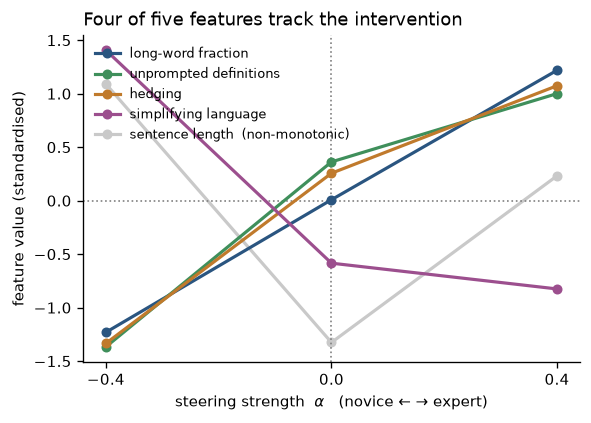

In [25]:
fig, ax = plt.subplots(figsize=(5.0, 3.6))
for k in FEATS:
    m = mu[k]
    z = (m - m.mean()) / (m.std() if m.std() > 0 else 1)
    flat = k in FLAT
    ax.plot(alphas, z, marker="o", ms=5, lw=1.9,
            color="#c9c9c9" if flat else COL[k],
            label=LABEL[k] + ("  (non-monotonic)" if k in NONMONO else ""),
            zorder=1 if flat else 3)
ax.axvline(0, ls=":", c="gray", lw=1)
ax.axhline(0, ls=":", c="gray", lw=1)
ax.set_xticks(alphas)
ax.set_xlabel("steering strength  $\\alpha$   (novice \u2190 \u2192 expert)")
ax.set_ylabel("feature value (standardised)")
ax.legend(frameon=False, fontsize=7.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Four of five features track the intervention", loc="left")
plt.tight_layout()
plt.savefig(RESULTS / "fig_steer_overlay.png", dpi=170, bbox_inches="tight")
plt.show()




In [2]:
import json
r = [json.loads(l) for l in open('results/behavior.jsonl')]
sel = [x for x in r if x['topic']=='python' and x['family']=='post' and x['template']==1]
for arm in ('novice','expert'):
    x = [y for y in sel if y['arm']==arm][0]
    print(f"--- {arm}\n{x['question']}\n{x['response'][:400]}\n")




--- novice
My python programming isn't working right. What should I check? I'm completely new to this.
Don't worry! Debugging is a normal part of learning any programming language. Since you are new to Python, here is a step-by-step checklist to help you find what's going wrong.

### 1. Read the Error Message (Crucial!)
Python is very helpful. If something goes wrong, it stops and tells you exactly what happened.
*   **Look for the `Traceback`**: This shows you which file and which line number caus

--- expert
My python programming isn't working right. What should I check? I've worked with this for years.
Even with years of experience, Python can be surprisingly tricky due to its dynamic nature, specific runtime behaviors, and how it interacts with the environment. Since you're an experienced developer, I'll skip the "check for typos" basics and jump straight into the high-leverage areas where seasoned engineers usually get stuck.

Here is a targeted checklist to debug your current iss

In [3]:
st = [json.loads(l) for l in open('results/steer_test.jsonl')]
q = "My python programming isn't working right. What should I check?"
for a in sorted({x['alpha'] for x in st}):
    hits = [x for x in st if x['alpha']==a and x['question']==q]
    if hits: print(f"--- alpha {a}\n{hits[0]['response'][:400]}\n")




--- alpha -0.4
Don't worry! Python is very beginner-friendly, and almost every error has a simple explanation. To help you fix your code, we need to figure out **what kind of problem** you are facing.

Here is a step-by-step guide on what to check, along with how we can work together to solve it.

### 1. The First Step: Look at the Error Message
This is the most important part! Python (and almost all programming

--- alpha 0.0
To help you debug your Python code effectively, please provide the following details. Without seeing the code and the error, it's difficult to pinpoint the exact issue:

1.  **The Error Message**: Copy and paste the full traceback from your terminal or console. This is the most important clue.
2.  **Your Code**: Paste the relevant part of the script where the error occurs.
3.  **What You Expected 

--- alpha 0.4
Since I don't have your specific code yet, here is a targeted checklist of the most common areas where Python scripts fail. Go through these systematical